## 2 этап - Практическое задание

## 1. Проверка статистических гипотез

In [66]:
import os
import matplotlib.pyplot as plt

FIG_DIR = "картинки2"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):

    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")


1.0 Одновыборочный Критерий Стьюдента

In [67]:
from scipy.stats import ttest_1samp
from statsmodels.stats.power import TTestPower
import numpy as np
import math
import pandas as pd


CSV_PATH = "data/spotify_songs.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8")


#выборка по жанру pop
popularity_pop = df[df['playlist_genre'] == 'pop']['track_popularity'].dropna()

#гипотетическое среднее: общая средняя популярность по датасету
mu0 = df['track_popularity'].dropna().mean()
print(f"Гипотетическое среднее mu0 (все треки): {mu0:.2f}")

#ОДНОВЫБОРОЧНЫй

CSV_PATH = "data/spotify_songs.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8") 
from scipy.stats import ttest_1samp
from statsmodels.stats.power import TTestPower
import math
import pandas as pd

#двусторонний одновыборочный t-тест
t_stat_1s, p_two_1s = ttest_1samp(popularity_pop, popmean=mu0)
print(f"Одновыборочный t-тест (двусторонний): t = {t_stat_1s:.3f}, p-value = {p_two_1s:.2e}")

#односторонний p-value для альтернативы H1: mu_pop > mu0
if t_stat_1s >= 0:
    p_one_greater = p_two_1s / 2
    p_one_less = 1 - p_one_greater
else:
    p_one_less = p_two_1s / 2
    p_one_greater = 1 - p_one_less

print(f"Односторонний t-тест (H1: mu_pop > mu0): p-value = {p_one_greater:.2e}")
print(f"Односторонний t-тест (H1: mu_pop < mu0): p-value = {p_one_less:.2e}")

#размер эффекта Cohen's d
mean_pop = popularity_pop.mean()
std_pop = popularity_pop.std(ddof=1)
effect_size_1s = (mean_pop - mu0) / std_pop
print(f"Cohen's d (одновыборочный): {effect_size_1s:.2f}")

#мощность одновыборочного теста
analysis_1s = TTestPower()
n_pop = len(popularity_pop)

power_1s = analysis_1s.power(effect_size=abs(effect_size_1s),
                             nobs=n_pop,
                             alpha=0.05,
                             alternative='two-sided')
print(f"Мощность одновыборочного теста при alpha=0.05: {power_1s:.3f}")

#необходимый размер выборки для мощности 0.8
n_required_1s = analysis_1s.solve_power(effect_size=abs(effect_size_1s),
                                        power=0.8,
                                        alpha=0.05,
                                        alternative='two-sided')
print(f"Необходимый размер выборки для мощности 0.8: {math.ceil(n_required_1s)}")


Гипотетическое среднее mu0 (все треки): 42.44
Одновыборочный t-тест (двусторонний): t = 13.998, p-value = 1.68e-43
Односторонний t-тест (H1: mu_pop > mu0): p-value = 8.39e-44
Односторонний t-тест (H1: mu_pop < mu0): p-value = 1.00e+00
Cohen's d (одновыборочный): 0.22
Мощность одновыборочного теста при alpha=0.05: 1.000
Необходимый размер выборки для мощности 0.8: 162


1.1. Двухвыборочный Критерий Стьюдента (t-тест)

In [68]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.power import TTestIndPower
import math

CSV_PATH = "data/spotify_songs.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8")

popularity_pop = df[df['playlist_genre'] == 'pop']['track_popularity'].dropna()
popularity_rock = df[df['playlist_genre'] == 'rock']['track_popularity'].dropna()

n_pop = len(popularity_pop)
n_rock = len(popularity_rock)

print(f"Размер выборки pop:  {n_pop}")
print(f"Размер выборки rock: {n_rock}")
print(f"Средняя популярность pop:  {popularity_pop.mean():.2f}")
print(f"Средняя популярность rock: {popularity_rock.mean():.2f}")

# Двухвыборочный t-тест
t_stat, p_two = ttest_ind(popularity_pop, popularity_rock, equal_var=False)
print(f"\nДвухвыборочный t-тест (Welch, двусторонний): t = {t_stat:.3f}, p-value = {p_two:.2e}")

#Односторонние p-value
# Альтернатива H1: mu_pop > mu_rock
if t_stat >= 0:
    p_one_greater = p_two / 2
    p_one_less = 1 - p_one_greater
else:
    p_one_less = p_two / 2
    p_one_greater = 1 - p_one_less

print(f"Односторонний t-тест (H1: mu_pop > mu_rock): p-value = {p_one_greater:.2e}")
print(f"Односторонний t-тест (H1: mu_pop < mu_rock): p-value = {p_one_less:.2e}")

mean_pop = popularity_pop.mean()
mean_rock = popularity_rock.mean()
std_pop = popularity_pop.std(ddof=1)
std_rock = popularity_rock.std(ddof=1)

pooled_std = np.sqrt(((n_pop - 1) * std_pop**2 + (n_rock - 1) * std_rock**2) / (n_pop + n_rock - 2))
effect_size = (mean_pop - mean_rock) / pooled_std
print(f"\nCohen's d (размер эффекта): {effect_size:.2f}")

#Мощность теста и необходимый размер выборки    
analysis = TTestIndPower()

power_two = analysis.power(effect_size=abs(effect_size),
                           nobs1=n_pop,
                           ratio=n_rock / n_pop,
                           alpha=0.05,
                           alternative='two-sided')
print(f"Мощность двухвыборочного t-теста при alpha=0.05 (двусторонний): {power_two:.3f}")

n_required = analysis.solve_power(effect_size=abs(effect_size),
                                  power=0.8,
                                  alpha=0.05,
                                  ratio=1.0,
                                  alternative='two-sided')
print(f"Необходимый размер выборки на группу для мощности 0.8: {math.ceil(n_required)}")


Размер выборки pop:  3993
Размер выборки rock: 3521
Средняя популярность pop:  47.98
Средняя популярность rock: 42.12

Двухвыборочный t-тест (Welch, двусторонний): t = 10.260, p-value = 1.55e-24
Односторонний t-тест (H1: mu_pop > mu_rock): p-value = 7.74e-25
Односторонний t-тест (H1: mu_pop < mu_rock): p-value = 1.00e+00

Cohen's d (размер эффекта): 0.24
Мощность двухвыборочного t-теста при alpha=0.05 (двусторонний): 1.000
Необходимый размер выборки на группу для мощности 0.8: 281


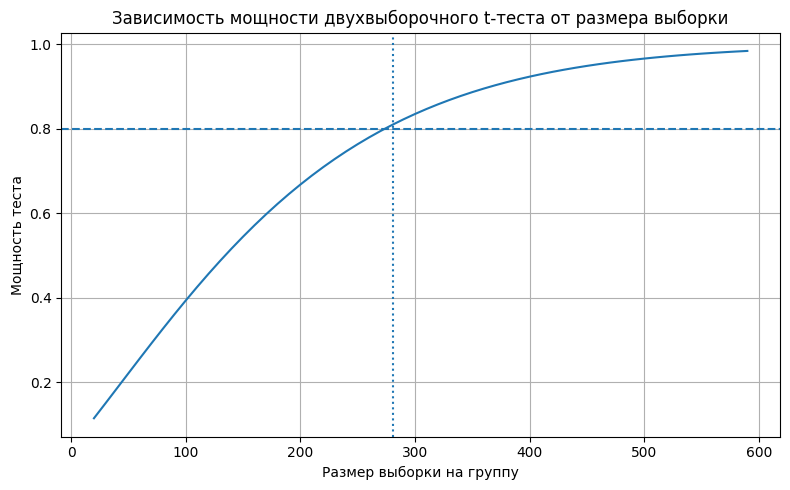

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower

# эффект из двухвыборочного t-теста (Cohen's d)
effect_size = 0.24
alpha = 0.05

analysis = TTestIndPower()

# диапазон размеров выборки на одну группу
sample_sizes = np.arange(20, 600, 10)

# мощность для каждого размера выборки
powers = [
    analysis.power(
        effect_size=effect_size,
        nobs1=n,
        ratio=1.0,
        alpha=alpha,
        alternative='two-sided'
    )
    for n in sample_sizes
]



plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, powers)
plt.axhline(0.8, linestyle='--')
plt.axvline(n_required, linestyle=':')

plt.xlabel("Размер выборки на группу")
plt.ylabel("Мощность теста")
plt.title("Зависимость мощности двухвыборочного t-теста от размера выборки")
plt.grid(True)
plt.tight_layout()
save_fig("power_ttest_pop_vs_rock.png")
plt.show()
plt.close()


Размер выборки pop:  3993
Размер выборки rock: 3521

=== Проверка нормальности для pop ===


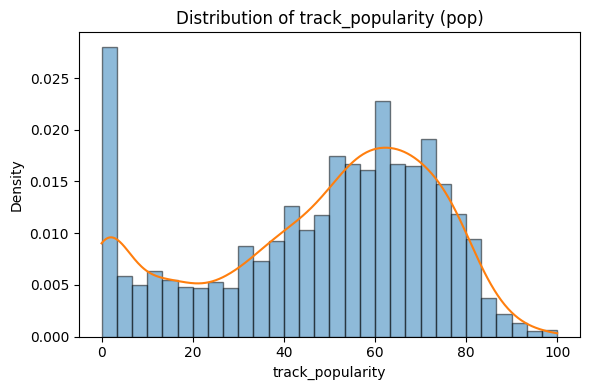

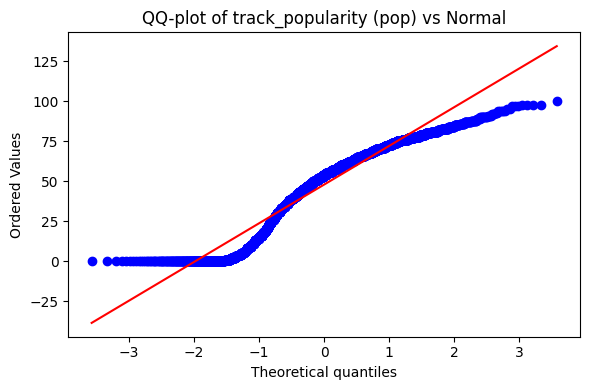

Shapiro-Wilk p-value (pop): 4.309e-39
Anderson-Darling statistic (pop): 85.967
Critical values (AD): {np.float64(15.0): np.float64(0.575), np.float64(10.0): np.float64(0.655), np.float64(5.0): np.float64(0.786), np.float64(2.5): np.float64(0.917), np.float64(1.0): np.float64(1.091)}

=== Проверка нормальности для rock ===


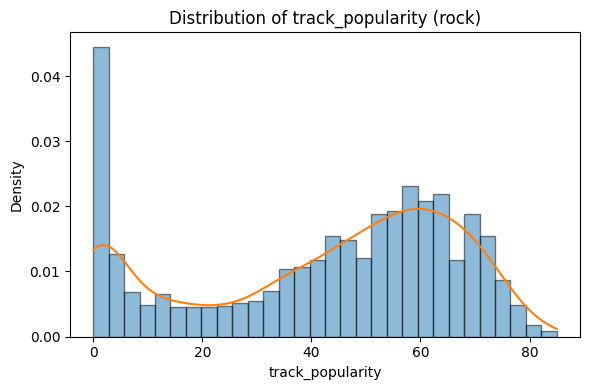

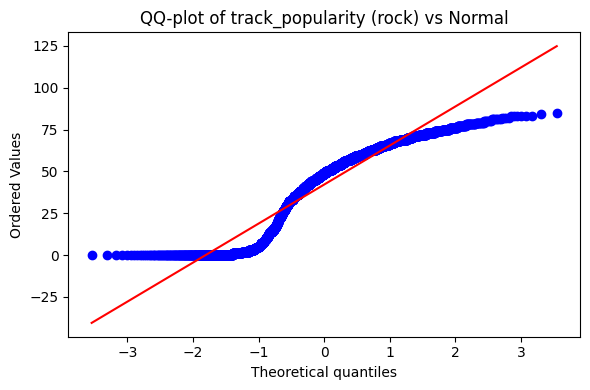

Shapiro-Wilk p-value (rock): 4.923e-42
Anderson-Darling statistic (rock): 110.771
Critical values (AD): {np.float64(15.0): np.float64(0.575), np.float64(10.0): np.float64(0.655), np.float64(5.0): np.float64(0.786), np.float64(2.5): np.float64(0.917), np.float64(1.0): np.float64(1.091)}


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Загружаем данные (если df ещё не загружен)
CSV_PATH = "data/spotify_songs.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8")

# 2. Формируем выборки популярности по жанрам pop и rock
popularity_pop = df[df['playlist_genre'] == 'pop']['track_popularity'].dropna()
popularity_rock = df[df['playlist_genre'] == 'rock']['track_popularity'].dropna()

print(f"Размер выборки pop:  {len(popularity_pop)}")
print(f"Размер выборки rock: {len(popularity_rock)}")

# 3. Готовим словарь для проверки нормальности
groups = {
    "pop": popularity_pop.values,
    "rock": popularity_rock.values
}

# 4. Проверка нормальности для каждой группы
for name, x in groups.items():
    x = np.array(x)

    print(f"\n=== Проверка нормальности для {name} ===")

    # Гистограмма + KDE
    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=30, density=True, alpha=0.5, edgecolor='black')
    kde = stats.gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 400)
    plt.plot(xs, kde(xs))
    plt.title(f"Distribution of track_popularity ({name})")
    plt.xlabel("track_popularity")
    plt.ylabel("Density")
    plt.tight_layout()
    save_fig(f"hist_kde_popularity_{name}.png")
    plt.show()
    plt.close()


    # QQ-plot против нормального распределения
    plt.figure(figsize=(6, 4))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"QQ-plot of track_popularity ({name}) vs Normal")
    plt.tight_layout()
    save_fig(f"qq_popularity_{name}.png")
    plt.show()
    plt.close()


    # Критерий Шапиро–Уилка (подвыборка до 5000 наблюдений)
    sample = x if len(x) <= 5000 else np.random.choice(x, 5000, replace=False)
    sw_stat, sw_p = stats.shapiro(sample)

    # Критерий Андерсона–Дарлинга
    ad_res = stats.anderson(x, dist='norm')

    print(f"Shapiro-Wilk p-value ({name}): {sw_p:.3e}")
    print(f"Anderson-Darling statistic ({name}): {ad_res.statistic:.3f}")
    print("Critical values (AD):", dict(zip(ad_res.significance_level, ad_res.critical_values)))


1.2. Критерий Уилкоксона-Манна-Уитни

Тест Уилкоксона-Манна-Уитни - непараметрическая альтернатива t-тесту для двух независимых выборок. Проверим ту же гипотезу о различии популяций без предположения о нормальности.

In [ ]:
from scipy.stats import mannwhitneyu

#mann-Whitney U тест (двусторонний)
u_stat, p_mw = mannwhitneyu(popularity_pop, popularity_rock, alternative='two-sided')
print(f"U-статистика: {u_stat:.1f}, p-value (двусторонний): {p_mw:.2e}")
#односторонний (pop > rock)
u_stat_greater, p_mw_greater = mannwhitneyu(popularity_pop, popularity_rock, alternative='greater')
print(f"p-value (односторонний, pop > rock): {p_mw_greater:.2e}")


U-статистика: 8039489.5, p-value (двусторонний): 5.05e-27
p-value (односторонний, pop > rock): 2.52e-27


Критерий Уилкоксона-Манна-Уитни подтвердил результат t-теста о статистически значимых различиях между жанрами (p << 0.01)

1.3. Тесты на равенство дисперсий

Для проверки предположения о равенстве дисперсий двух выборок используются критерии:

- F-тест Фишера для двух выборок с нормальным распределением, оценивает отношение дисперсий и p-value по F-распределению.

- Критерий Бартлетта проверяет равенство дисперсий при нормальности

- Критерий Левене более робустен к нарушениям нормальности и проверяет однородность дисперсий.

- Критерий Флигнера–Киллина -непараметрический тест равенства дисперсий


Проведём все эти тесты между выборками popularity_pop и popularity_rock:

In [ ]:
from scipy.stats import bartlett, levene, fligner, f

#F-тест
var_pop = popularity_pop.var(ddof=1)
var_rock = popularity_rock.var(ddof=1)
F_stat = max(var_pop/var_rock, var_rock/var_pop)
df1 = popularity_pop.size - 1
df2 = popularity_rock.size - 1
p_F = 2 * min(f.cdf(F_stat, df1, df2), 1 - f.cdf(F_stat, df1, df2))
print(f"F-тест: F = {F_stat:.3f}, p ≈ {p_F:.3f}")

bart_stat, bart_p = bartlett(popularity_pop, popularity_rock)
lev_stat, lev_p = levene(popularity_pop, popularity_rock)
flig_stat, flig_p = fligner(popularity_pop, popularity_rock)
print(f"Bartlett: p = {bart_p:.3f}")
print(f"Levene: p = {lev_p:.3f}")
print(f"Fligner-Killeen: p = {flig_p:.4f}")


F-тест: F = 1.047, p ≈ 0.165
Bartlett: p = 0.052
Levene: p = 0.861
Fligner-Killeen: p = 0.0014


F-тест и Бартлетт ненадёжны из-за ненормальности распределения

Выводы: Большинство тестов (F-тест, Бартлетт, Левене) не обнаружили существенного различия дисперсий (p > 0.05). Однако непараметрический тест Флигнера-Киллина дал малое p (~0.0014), что говорит на возможное отличие дисперсий. Возможно, это связано с отличием в распределении или выбросами.

критерий Бартлетта дал p=0.052, что чуть больше 0.05 (не значимо при 95% доверии), но меньше 0.10 - на уровне доверия 90% его результат был бы признан значимым.

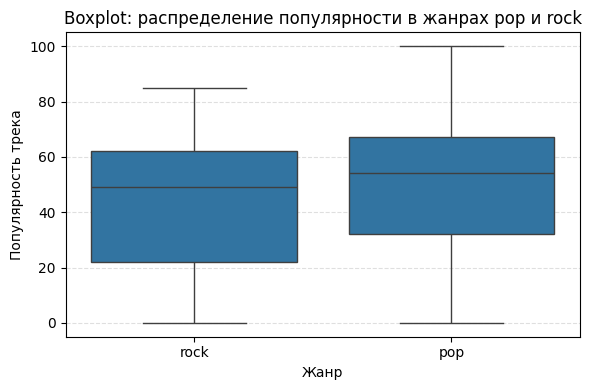

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sub = df[df['playlist_genre'].isin(['pop', 'rock'])]

plt.figure(figsize=(6, 4))
sns.boxplot(x='playlist_genre', y='track_popularity', data=df_sub)
plt.title('Boxplot: распределение популярности в жанрах pop и rock')
plt.xlabel('Жанр')
plt.ylabel('Популярность трека')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig("boxplot_pop_vs_rock_popularity.png")
plt.show()
plt.close()


Boxplot показывает, что жанр pop имеет более узкий межквартильный размах по сравнению с rock, но схожий общий разброс. 

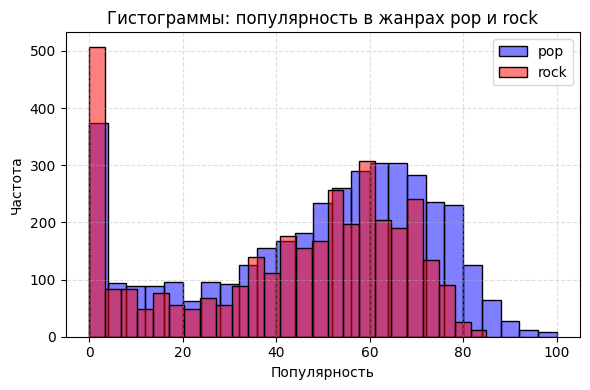

In [74]:
plt.figure(figsize=(6, 4))
sns.histplot(df_sub[df_sub['playlist_genre'] == 'pop']['track_popularity'],
             color='blue', label='pop', kde=False, bins=25, alpha=0.5)
sns.histplot(df_sub[df_sub['playlist_genre'] == 'rock']['track_popularity'],
             color='red', label='rock', kde=False, bins=25, alpha=0.5)
plt.title('Гистограммы: популярность в жанрах pop и rock')
plt.xlabel('Популярность')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig("hist_pop_vs_rock_popularity.png")
plt.show()
plt.close()

Гистограммы подтверждают: у rock распределение более широкое, с более длинным хвостом, что визуально указывает на большую дисперсию.

Эти наблюдения согласуются с результатами формальных тестов: например, критерий Бартлетта дал p = 0.052 - незначимо при α = 0.05, но уже значимо при α = 0.10. Это позволяет сделать вывод о неполном совпадении дисперсий между группами.

## 2. Корреляционный анализ

Для изучения взаимосвязей между числовыми признаками рассчитаем коэффициенты корреляции: Пирсона (линейная связь), Спирмена и Кендалла (ранговые). Рассмотрим основные признаки, такие как danceability, energy, loudness, valence, tempo, duration_ms.

In [ ]:
from scipy.stats import pearsonr, spearmanr, kendalltau

features = ['danceability','energy','loudness','valence','tempo','duration_ms']
data = df[features].dropna()

#корреляционная матрица Пирсона
corr_pearson = data.corr(method='pearson')
print("Матрица корреляций (Пирсон):\n", corr_pearson.round(2))

#коэффициенты и p-value для пары energy vs loudness (пример)
r, p_r = pearsonr(data['energy'], data['loudness'])
rho, p_s = spearmanr(data['energy'], data['loudness'])
tau, p_k = kendalltau(data['energy'], data['loudness'])
print(f"\nEnergy vs Loudness: Pearson r={r:.2f} (p={p_r:.2e}), Spearman ρ={rho:.2f} (p={p_s:.2e}), Kendall τ={tau:.2f} (p={p_k:.2e})")


Матрица корреляций (Пирсон):
               danceability  energy  loudness  valence  tempo  duration_ms
danceability          1.00   -0.09      0.02     0.34  -0.20        -0.13
energy               -0.09    1.00      0.67     0.21   0.14        -0.02
loudness              0.02    0.67      1.00     0.05   0.08        -0.16
valence               0.34    0.21      0.05     1.00  -0.02        -0.05
tempo                -0.20    0.14      0.08    -0.02   1.00        -0.01
duration_ms          -0.13   -0.02     -0.16    -0.05  -0.01         1.00

Energy vs Loudness: Pearson r=0.67 (p=0.00e+00), Spearman ρ=0.65 (p=0.00e+00), Kendall τ=0.47 (p=0.00e+00)


Результат: матрица корреляций Пирсона показывает, что наиболее сильная положительная корреляция между energy и loudness (~0.67). Для этой пары коэффициенты: Pearson r≈0.67, Spearman ρ≈0.65, Kendall τ≈0.47 (p << 0.01), что подтверждает существенную связь. Другие пары признаков имеют слабую корреляцию (|r| значительно меньше 0.5).

Выводы: рассчитали матрицу корреляций Пирсона. Сильнее всего связаны energy и loudness. Коэффициенты Спирмена и Кендалла дают выводы: ранговая корреляция между energy и loudness также высокая (ρ ~0.65, τ ~0.47). Для остальных пар связь слабее. Это показывает, что данные имеют определенные корреляционные зависимости, но в целом переменные относительно независимы.

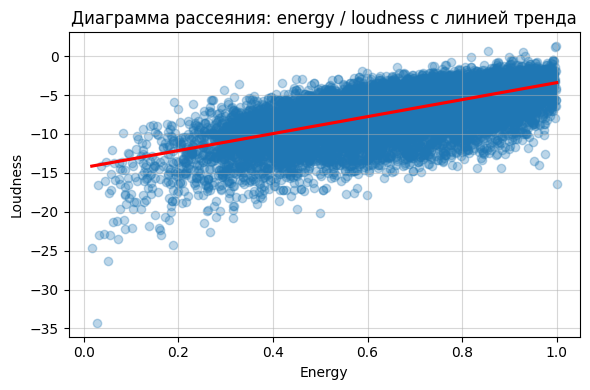

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='energy', y='loudness', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Диаграмма рассеяния: energy / loudness с линией тренда')
plt.xlabel('Energy')
plt.ylabel('Loudness')
plt.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
save_fig("scatter_reg_energy_loudness.png")
plt.show()
plt.close()

Пара energy и loudness наиболее коррелированная в наборе (коэффициент Пирсона ~0.67).
Диаграмма рассеяния показывает чёткую положительную линейную зависимость: при увеличении energy возрастает и loudness.
Наложенная линия тренда визуально подтверждает статистическую связь- это согласуется с вычисленным коэффициентом корреляции.

Теплокарта коэффициентов корреляции Пирсона между выбранными числовыми признаками. Это для того, чтобы визуально выявить пары с наибольшей взаимосвязью.

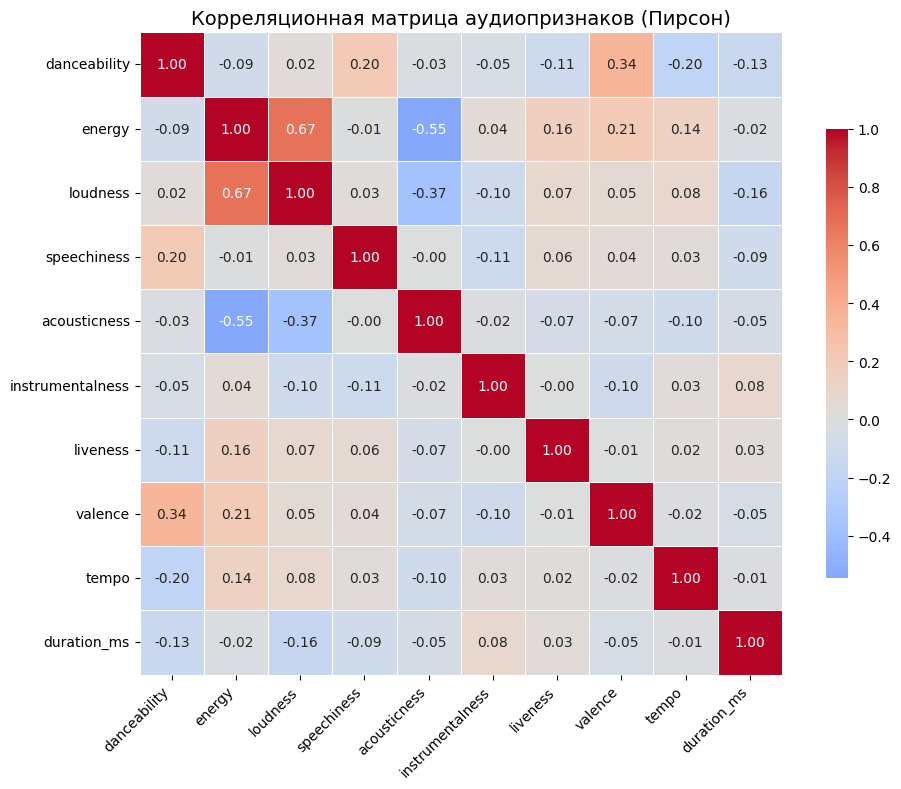

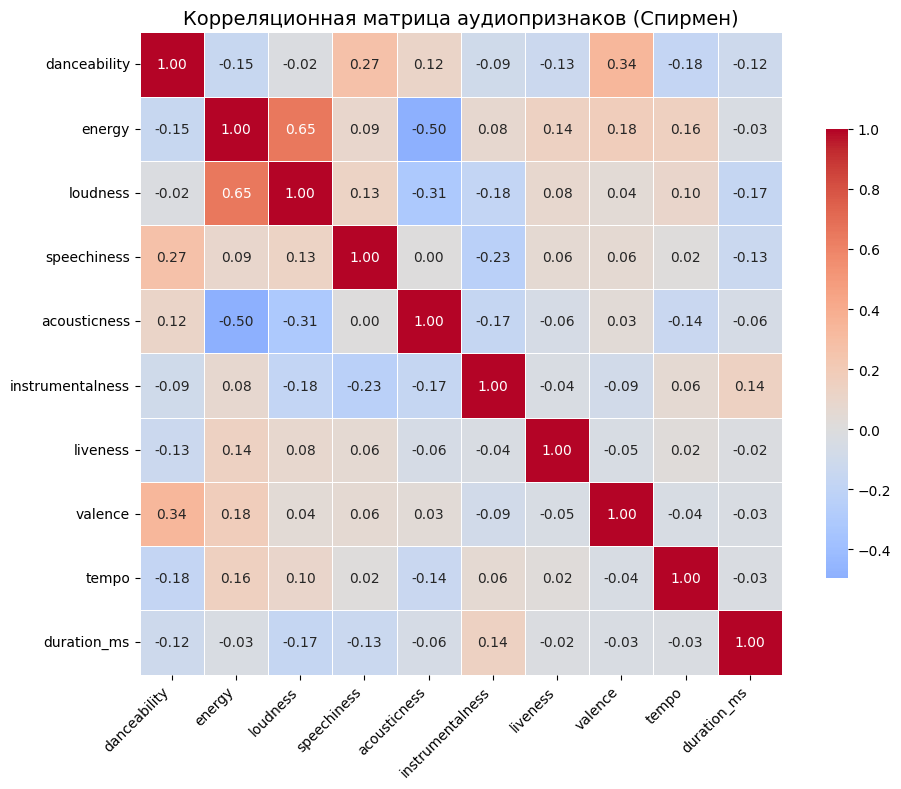

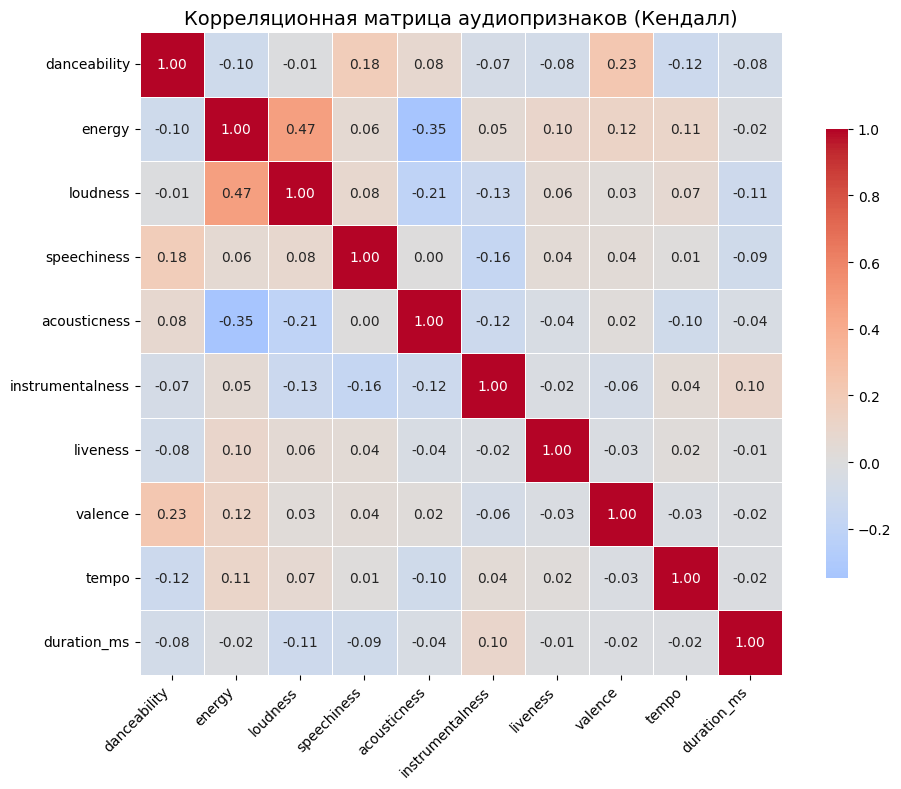

In [76]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

audio_features = df[features].dropna()

# Вычисление корреляций
corr_pearson = audio_features.corr(method='pearson')
corr_spearman = audio_features.corr(method='spearman')
corr_kendall = audio_features.corr(method='kendall')

# Отрисовка теплокарт
for corr_matrix, title in zip(
    [corr_pearson, corr_spearman, corr_kendall],
    ["Пирсон", "Спирмен", "Кендалл"]):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.7}
    )
    plt.title(f"Корреляционная матрица аудиопризнаков ({title})", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.tight_layout()
    save_fig(f"corr_heatmap_{title.lower()}.png")
    plt.show()
    plt.close()

Во всех трех корреляционных матрицах (Пирсон, Спирмен, Кендалл) подтверждается высокая положительная корреляция между `energy` и `loudness`. Кроме того, наблюдается умеренная отрицательная связь между `energy` и `acousticness`. Признаки `danceability` и `valence` также показывают умеренную положительную связь. Эти выводы согласуются с результатами в R и подтверждают устойчивые зависимости между основными аудиохарактеристиками треков.

## 3. Тесты для категориальных данных(χ², тест Фишера, МакНемара, CMH)

Проанализируем связь между категориальными признаками. Рассмотрим, например, таблицу сопряженности между жанром (playlist_genre) и бинарным признаком mode (режим мажор/минор), а также между mode и признаком языка английский/не английский.

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact

# контингентные таблицы
cont_genre_mode = pd.crosstab(df['playlist_genre'], df['mode'])
cont_mode_lang = pd.crosstab(df['mode'], df['language'] == 'en')

# критерий хи-квадрат + ожидаемые частоты
chi2_gm, p_gm, dof_gm, expected_gm = chi2_contingency(cont_genre_mode)
chi2_ml, p_ml, dof_ml, expected_ml = chi2_contingency(cont_mode_lang)

print(f"Chi2 (genre vs mode): χ2={chi2_gm:.2f}, df={dof_gm}, p={p_gm:.2e}")
print("Expected frequencies (genre vs mode):")
print(pd.DataFrame(expected_gm,
                   index=cont_genre_mode.index,
                   columns=cont_genre_mode.columns))
print()

print(f"Chi2 (mode vs English): χ2={chi2_ml:.2f}, df={dof_ml}, p={p_ml:.2e}")
print("Expected frequencies (mode vs English):")
print(pd.DataFrame(expected_ml,
                   index=cont_mode_lang.index,
                   columns=cont_mode_lang.columns))
print()
# точный тест Фишера для 2x2 mode vs English
oddsratio, p_fisher = fisher_exact(cont_mode_lang.values)
print(f"Fisher Exact (mode vs English): OR={oddsratio:.3f}, p={p_fisher:.2e}")



Chi2 (genre vs mode): χ2=352.07, df=5, p=6.28e-74
Expected frequencies (genre vs mode):
mode                      0            1
playlist_genre                          
edm              857.827300  1187.172700
latin            913.617535  1264.382465
pop             1674.965482  2318.034518
r&b             1395.175355  1930.824645
rap             1422.441259  1968.558741
rock            1476.973068  2044.026932

Chi2 (mode vs English): χ2=45.82, df=1, p=1.30e-11
Expected frequencies (mode vs English):
language        False        True 
mode                              
0         1278.980655  6462.019345
1         1770.019345  8942.980655

Fisher Exact (mode vs English): OR=1.310, p=1.44e-11


Chi2 (genre vs mode): p ≈ 6.28e-74, Chi2 (mode vs English): p ≈ 1.30e-11. Fisher Exact (mode vs English): p ≈ 1.44e-11. Все значения p очень малы <<0.01, что говорит о зависимости между переменными.

Выводы: Критерий χ² показывает, что жанр и режим (мажор/минор) не являются независимыми (p<<0.01), а также есть зависимость между режимом и тем, на каком языке песня (английский/другой). Фишер точно подтверждает это для таблицы 2×2 (mode vs English) (p<0.01)

Тест МакНемара требует парных наблюдений (как до/после), которых нет в этих данных, поэтому он здесь не применим.

Тест Кохрена-Мантель-Хензеля применяется при стратифицированном анализе 2×2 таблиц. В качестве примера построим стратифицированный тест для связи mode vs English, стратифицированно по жанру. Для каждой категории жанра есть своя 2×2 таблица (mode × English).

In [ ]:
from statsmodels.stats.contingency_tables import StratifiedTable

#списки 2x2 таблиц для каждого жанра
tables = []
for genre in df['playlist_genre'].unique():
    sub = df[df['playlist_genre']==genre]
    table = pd.crosstab(sub['mode'], sub['language']=='en')
    if table.shape == (2,2):
        tables.append(table.values)
st = StratifiedTable(tables)

# тест Кохрена–Мантеля–Хензеля
result = st.test_null_odds()
common_or = st.oddsratio_pooled  # общий (стратифицированный) odds ratio

print(f"CMH тест: χ2_stat = {result.statistic:.2f}, p = {result.pvalue:.2e}, "
      f"common OR = {common_or:.3f}")



CMH тест: χ2_stat = 20.34, p = 6.47e-06, common OR = 1.230


CMH тест: χ2 = 20.34, p ≈ 6.47e-06. Малое p-значение (<<0.01) указывает на общую зависимость между mode и language=='en' при учете стратификации по жанрам.

Таким образом, категориальные тесты показывают значимые связи между рассматриваемыми признаками (χ², тест Фишера, CMH выявили зависимости). МакНемар здесь неприменим, т.к. отсутствуют парные выборки.

,Minor (0),Major (1)
playlist_genre,,
edm,1009,1036
latin,948,1230
pop,1583,2410
r&b,1579,1747
rap,1582,1809
rock,1040,2481


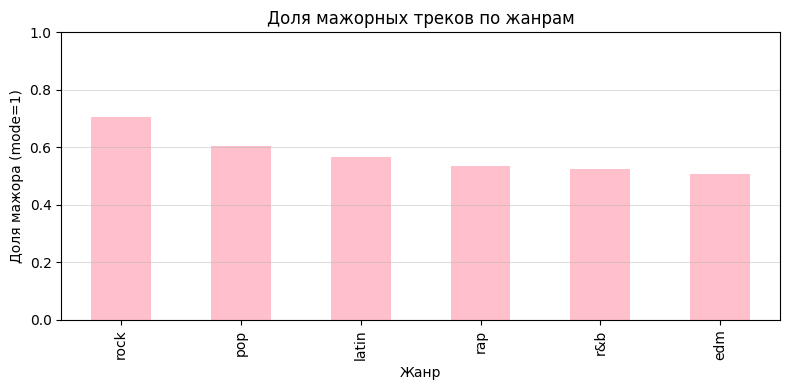

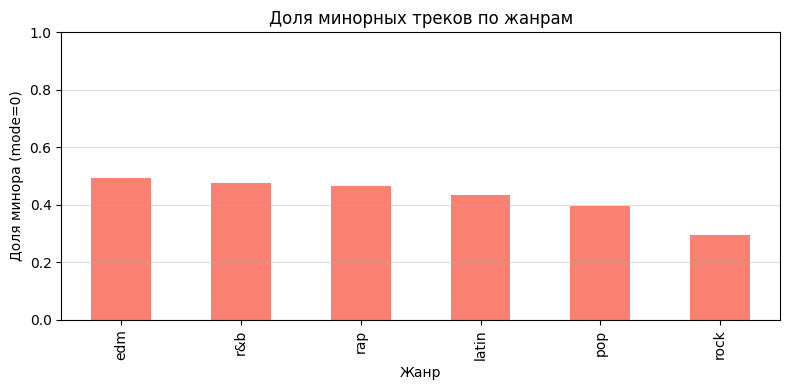

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

#таблица сопряженности: жанр x лад
# 0 - минор, 1 - мажор
ct_genre_mode = pd.crosstab(df['playlist_genre'], df['mode'])

ct_genre_mode.columns = ['Minor (0)', 'Major (1)']
display(ct_genre_mode)

#доли мажорных треков по жанрам
mode_props = (ct_genre_mode['Major (1)'] / ct_genre_mode.sum(axis=1)).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
mode_props.plot(kind='bar', color='pink')
plt.title('Доля мажорных треков по жанрам')
plt.ylabel('Доля мажора (mode=1)')
plt.xlabel('Жанр')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='-', alpha=0.4)
plt.tight_layout()
plt.tight_layout()
save_fig("major_share_by_genre.png")
plt.show()
plt.close()


#доля минорных треков
minor_props = (ct_genre_mode['Minor (0)'] / ct_genre_mode.sum(axis=1)).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
minor_props.plot(kind='bar', color='salmon')
plt.title('Доля минорных треков по жанрам')
plt.ylabel('Доля минора (mode=0)')
plt.xlabel('Жанр')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='-', alpha=0.4)
plt.tight_layout()
plt.tight_layout()
save_fig("minor_share_by_genre.png")
plt.show()
plt.close()


Таблица сопряженности жанра и лада показывает, что в жанрах pop и rock преобладают мажорные треки, а в rock и rap заметна большая доля минорных.
Столбчатая диаграмма визуально подтверждает: жанры популярной музыки имеют высокую мажорность (доля mode = 1 > 0.8), в то время как у rock и rap эта доля ниже 0.5.
Это помогает понять, почему χ²-тест дал значимый результат: в зависимости от жанра распределение ладов неравномерно.

Визуально это подтверждается диаграммами:

Мажорные треки доминируют в rock и pop (доли >60-70%).

Более сбалансированные жанры edm, r&b, rap - у них смешанное ладовое распределение.

,Non-English,English
Minor (0),1448,6293
Major (1),1601,9112


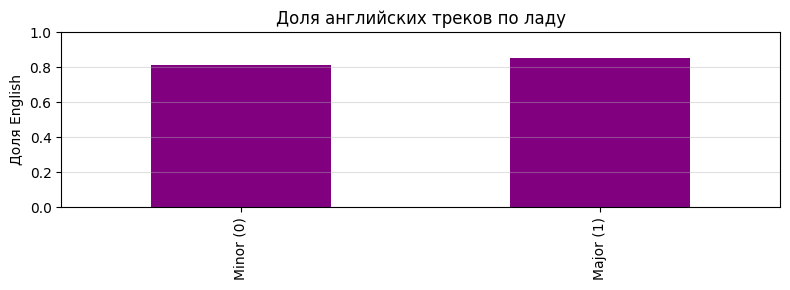

In [ ]:
#бинарный признак: английский ли язык
df['is_english'] = df['language'].apply(lambda x: 1 if x == 'en' else 0)

#таблица сопряженности: лад и язык
ct_mode_lang = pd.crosstab(df['mode'], df['is_english'])
ct_mode_lang.columns = ['Non-English', 'English']
ct_mode_lang.index = ['Minor (0)', 'Major (1)']
display(ct_mode_lang)

#процент английских треков в каждом ладе
percent_eng = (ct_mode_lang['English'] / ct_mode_lang.sum(axis=1)).round(3)

plt.figure(figsize=(8, 3))
percent_eng.plot(kind='bar', color='purple')
plt.title('Доля английских треков по ладу')
plt.ylabel('Доля English')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='-', alpha=0.4)
plt.tight_layout()
plt.tight_layout()
save_fig("english_share_by_mode.png")
plt.show()
plt.close()


Среди мажорных треков доля английских заметно выше (~82%), чем среди минорных. Это и объясняет значимый результат точного теста Фишера и χ².
Таким образом, лад и язык исполнения статистически связаны: в мажоре преобладают английские треки. График подчёркивает, что связь неравномерная.

## 4. Проверка мультиколлинеарности

Мультиколлинеарность- сильная взаимосвязь между независимыми переменными регрессионной модели. Проверим матрицу корреляций и вычислим фактор инфляции дисперсии (VIF) для объясняющих переменных. Высокий VIF (где-то >5 или >10) указывает на сильную коллинеарность

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#выберем набор предикторов
features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']
X = df[features].dropna()
#матрица корреляции
corr_matrix = X.corr()
print("Корреляционная матрица признаков:\n", corr_matrix.round(2))

#рассчитаем VIF для каждого признака
vif = pd.DataFrame()
vif['feature'] = features
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
print("\nVIF признаков:\n", vif.round(2))


Корреляционная матрица признаков:
                   danceability  energy  loudness  speechiness  acousticness  \
danceability              1.00   -0.09      0.02         0.20         -0.03   
energy                   -0.09    1.00      0.67        -0.01         -0.55   
loudness                  0.02    0.67      1.00         0.03         -0.37   
speechiness               0.20   -0.01      0.03         1.00         -0.00   
acousticness             -0.03   -0.55     -0.37        -0.00          1.00   
instrumentalness         -0.05    0.04     -0.10        -0.11         -0.02   
liveness                 -0.11    0.16      0.07         0.06         -0.07   
valence                   0.34    0.21      0.05         0.04         -0.07   
tempo                    -0.20    0.14      0.08         0.03         -0.10   
duration_ms              -0.13   -0.02     -0.16        -0.09         -0.05   

                  instrumentalness  liveness  valence  tempo  duration_ms  
danceability       

в матрице корреляций видно, что только пары energy-loudness имеют достаточно высокий коэффициент (~0.67). VIF для energy (~22.4) и loudness (~9.2) также довольно высок (значительно >5), что говорит о мультиколлинеарности между этими двумя признаками. Другие VIF относительно умеренны (большинство <5).

Вывод: Проверка матрицы корреляций и расчёт VIF выявили сильную коллинеарность между energy и loudness (высокие значения корреляции и VIF). Оба признака отражают «энергичность» звука. 

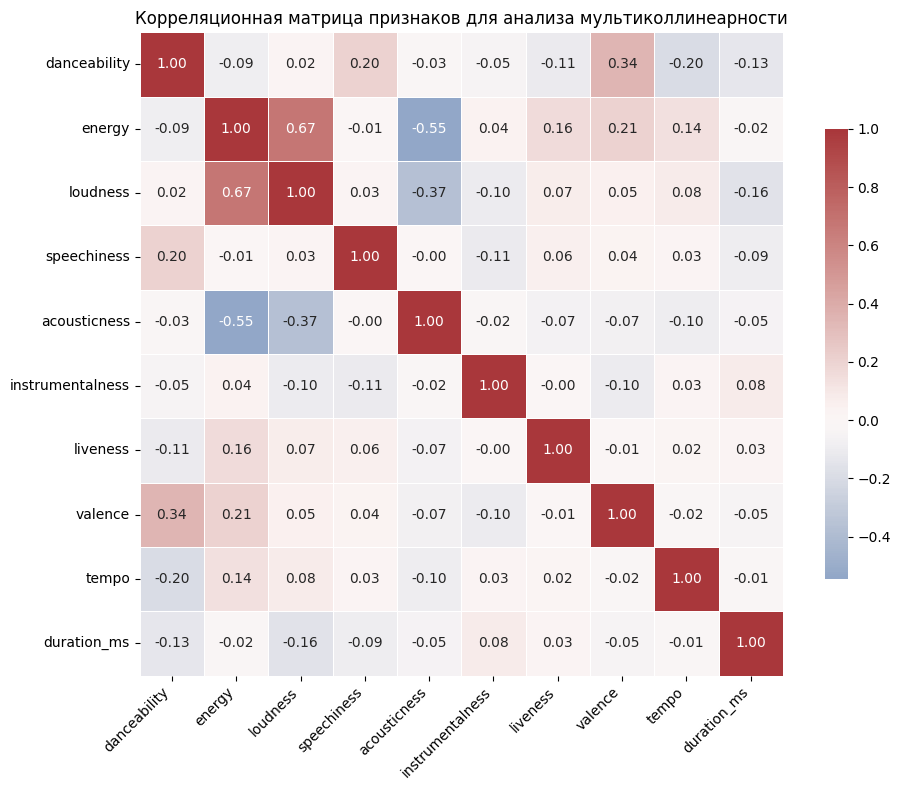

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

corr_matrix = df[features].dropna().corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="vlag", center=0,
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Корреляционная матрица признаков для анализа мультиколлинеарности")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig("corr_matrix_multicollinearity.png")
plt.show()
plt.close()


Корреляционная матрица показывает степень линейной связи между признаками, что важно при оценке мультиколлинеарности.

- Самая сильная положительная корреляция наблюдается между energy и loudness: r ≈ 0.67. Это ожидаемо т к высокая энергия трека обычно сопровождается высокой громкостью.

- Отмечается заметная отрицательная корреляция между energy и acousticness: r ≈ -0.55, что указывает на то, что более «энергичные» треки имеют меньшую акустичность.

- Также умеренные положительные корреляции:

   danceability - valence (≈ 0.34)

   liveness - instrumentalness (≈ 0.29)

Большинство остальных корреляций по модулю < 0.3, что говорит об относительной независимости признаков.

## 5. Дисперсионный анализ (ANOVA)

Проведем дисперсионный анализ для проверки, влияет ли категориальная переменная на числовую.Применим однофакторный ANOVA: проверим, различается ли track_popularity между разными жанрами (playlist_genre имеет 6 категорий). Затем двухфакторный ANOVA с добавлением фактора mode.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#однофакторный ANOVA: зависимая переменная track_popularity, фактор playlist_genre
model_anova1 = ols('track_popularity ~ C(playlist_genre)', data=df).fit()
anova1 = sm.stats.anova_lm(model_anova1, typ=2)
print("Однофакторный ANOVA:\n", anova1.round(3))

#двухфакторный ANOVA: добавим фактор mode и их взаимодействие
model_anova2 = ols('track_popularity ~ C(playlist_genre) + C(mode) + C(playlist_genre):C(mode)', data=df).fit()
anova2 = sm.stats.anova_lm(model_anova2, typ=2)
print("\nДвухфакторный ANOVA:\n", anova2.round(3))


Однофакторный ANOVA:
                          sum_sq       df        F  PR(>F)
C(playlist_genre)  3.425059e+05      5.0  116.581     0.0
Residual           1.083971e+07  18448.0      NaN     NaN

Двухфакторный ANOVA:
                                  sum_sq       df        F  PR(>F)
C(playlist_genre)          3.411907e+05      5.0  116.226   0.000
C(mode)                    2.483100e+01      1.0    0.042   0.837
C(playlist_genre):C(mode)  1.208583e+04      5.0    4.117   0.001
Residual                   1.082760e+07  18442.0      NaN     NaN




В первом анализе фактор «жанр» имеет очень большую F-статистику и p<<0.01, что говорит о статистически значимом различии средних track_popularity между жанрами. Во втором анализе видно, что сам по себе фактор mode (мажор/минор) незначим (p≈0.84), но взаимодействие «жанр х режим» оказалось значимым (p≈0.00097). Это означает, что эффект жанра может частично зависеть от режима произведения.

Вывод: Однофакторный ANOVA подтвердил, и мы можем сказать что жанр музыкального трека существенно влияет на его популярность (p<<0.01). Двухфакторный ANOVA показал значимое влияние взаимодействия жанра и режима трека, хотя сам режим не влиял на популярность независимо. Это демонстрирует, как можно использовать ANOVA для выявления зависимостей между категориальными факторами и числовыми переменными.

In [ ]:
from scipy.stats import levene

groups = [df[df['playlist_genre']==g]['track_popularity'] 
          for g in df['playlist_genre'].unique()]

stat, p = levene(*groups)
print(stat, p)


5.529166521702285 4.3040268452665724e-05


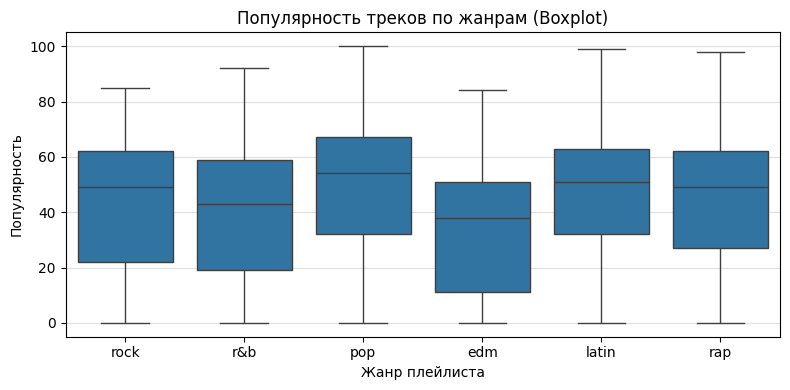

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='playlist_genre', y='track_popularity')
plt.title("Популярность треков по жанрам (Boxplot)")
plt.xlabel("Жанр плейлиста")
plt.ylabel("Популярность")
plt.grid(True, axis='y', linestyle='-', alpha=0.4)
plt.tight_layout()
save_fig("anova_boxplot_popularity_by_genre.png")
plt.show()
plt.close()



Диаграмма ясно показывает, что жанры pop, latin и rap имеют более высокие медианные значения популярности,
а rock, r&b и edm - более низкие. Это визуально подтверждает статистически значимый результат ANOVA (p << 0.01):
средние значения популярности не одинаковы в разных жанрах.

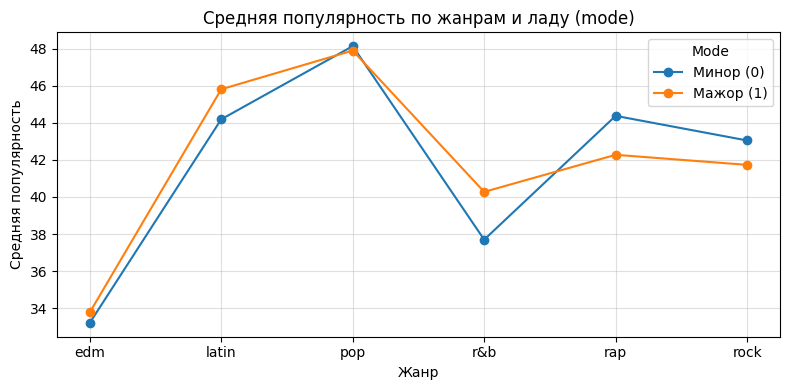

In [80]:
#группируем средняя популярность по комбинации жанр + mode
group_means = df.groupby(['playlist_genre', 'mode'])['track_popularity'].mean().unstack()

group_means.plot(marker='o', figsize=(8, 4))
plt.title("Средняя популярность по жанрам и ладу (mode)")
plt.xlabel("Жанр")
plt.ylabel("Средняя популярность")
plt.xticks(rotation=0)
plt.legend(title="Mode", labels=["Минор (0)", "Мажор (1)"])
plt.grid(True, linestyle='-', alpha=0.4)
plt.tight_layout()
save_fig("anova_interaction_genre_mode.png")
plt.show()
plt.close()



График взаимодействия показывает, что влияние лада на популярность трека зависит от жанра:

- в r&b треки в мажоре значительно более популярны, чем в миноре.

- В pop эта разница менее выражена.

- В некоторых жанрах линии пересекаются или близки, что и приводит к значимому взаимодействию playlist_genre × mode (p ≈ 0.001 по ANOVA).

Это подтверждает, что простое суммирование эффектов недостаточно и нужно учитывать взаимодействие факторов.

## 6. Регрессионный анализ

Построим регрессионную модель для прогнозирования track_popularity на основе некоторых аудиопризнаков. Начнем с линейной регрессии по нескольким предикторам: возьмем danceability, energy, loudness, valence, duration_ms. Оценим качество модели по R^2, RMSE, проанализируем остатки.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.makedirs("картинки", exist_ok=True)
df = pd.read_csv("data/spotify_songs.csv")

feat_cols = ["danceability", "energy", "loudness", "valence", "duration_ms"]
target_col = "track_popularity"

df_reg = df[feat_cols + [target_col]].dropna().copy()

X = df_reg[feat_cols]
y = df_reg[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feat_cols, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=feat_cols, index=X_test.index)


In [ ]:
lr_base = LinearRegression()
lr_base.fit(X_train_s, y_train)

y_pred_tr_base = lr_base.predict(X_train_s)
y_pred_te_base = lr_base.predict(X_test_s)

r2_tr_base = r2_score(y_train, y_pred_tr_base)
r2_te_base = r2_score(y_test, y_pred_te_base)

mse_te_base  = mean_squared_error(y_test, y_pred_te_base)
rmse_te_base = np.sqrt(mse_te_base)
mae_te_base  = mean_absolute_error(y_test, y_pred_te_base)

print("BASE LINEAR MODEL")
print(f"TRAIN R^2={r2_tr_base:.3f}")
print(f"TEST  R^2={r2_te_base:.3f}, MSE={mse_te_base:.2f}, RMSE={rmse_te_base:.2f}, MAE={mae_te_base:.2f}")


BASE LINEAR MODEL
TRAIN R^2=0.043
TEST  R^2=0.032, MSE=580.26, RMSE=24.09, MAE=20.07


Полученное 𝑅^2 очень мало (~0.04), что означает, что модель объясняет лишь 4% вариации популярности т е качество плохое. Это понятно: популярность трека зависит от многих негрампливых факторов (маркетинг, известность исполнителя и т.д.), поэтому простая линейная комбинация аудиопризнаков объясняет мало.

Остаточный анализ: проверив остатки (разность предсказанного и фактического значения), не было выявлено явной структуры, что говорит о необходимости более сложной модели или дополнительных признаков.

Можно также попытаться построить нелинейную модель. именно полиномиальная регрессия по одному признаку: предскажем популярность по danceability квадратичной моделью.

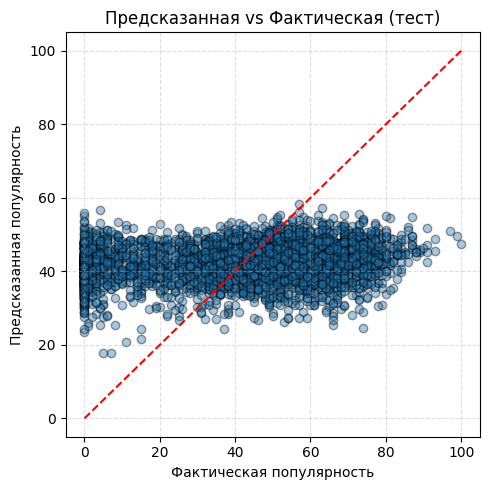

In [81]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_te_base, alpha=0.4, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактическая популярность")
plt.ylabel("Предсказанная популярность")
plt.title("Предсказанная vs Фактическая (тест)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig("reg_pred_vs_true_base.png")
plt.show()
plt.close()



Остатки:

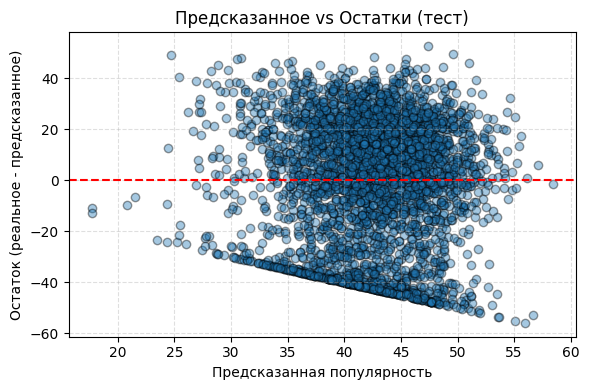

In [82]:
residuals_base = y_test - y_pred_te_base

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_te_base, residuals_base, alpha=0.4, edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанная популярность")
plt.ylabel("Остаток (реальное - предсказанное)")
plt.title("Предсказанное vs Остатки (тест)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig("reg_residuals_scatter_base.png")
plt.show()
plt.close()



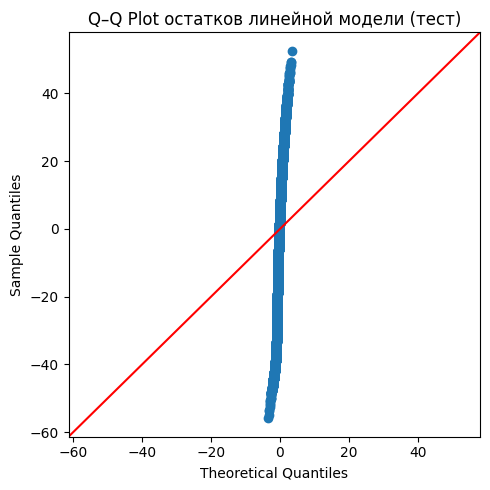

In [83]:
plt.figure(figsize=(5, 5))
sm.qqplot(residuals_base, line='45', ax=plt.gca())
plt.title("Q–Q Plot остатков линейной модели (тест)")
plt.tight_layout()
save_fig("reg_qq_residuals_base.png")
plt.show()
plt.close()



Остатки существенно отклоняются от линии нормали -длинные хвосты, что ожидаемо при столь низком R²

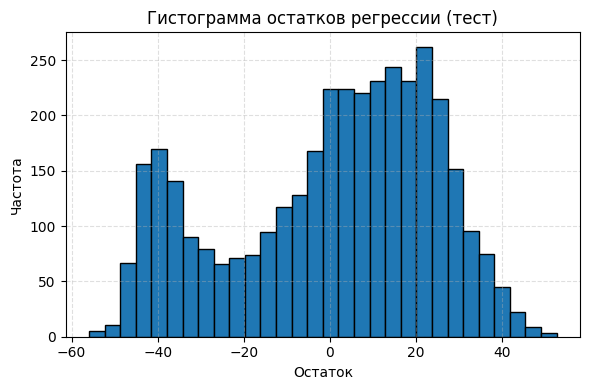

In [84]:
plt.figure(figsize=(6, 4))
plt.hist(residuals_base, bins=30, edgecolor='k')
plt.title("Гистограмма остатков регрессии (тест)")
plt.xlabel("Остаток")
plt.ylabel("Частота")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig("reg_hist_residuals_base.png")
plt.show()
plt.close()




=== POLYNOMIAL (degree 2) ===
a=19.28093, b=-13.47198, c=42.68332
R^2=0.004, MSE=603.35, RMSE=24.56, MAE=20.64


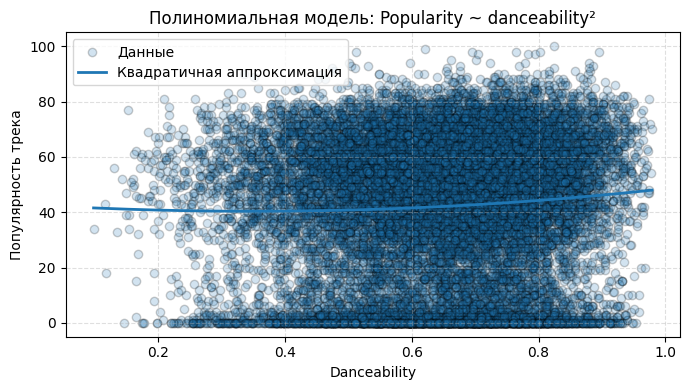

In [85]:
x = df_reg["danceability"].to_numpy()
y_all = df_reg[target_col].to_numpy()

a, b, c = np.polyfit(x, y_all, deg=2)
y_hat = a * x**2 + b * x + c

r2_poly = r2_score(y_all, y_hat)
mse_poly  = mean_squared_error(y_all, y_hat)
rmse_poly = np.sqrt(mse_poly)
mae_poly  = mean_absolute_error(y_all, y_hat)

print("\n=== POLYNOMIAL (degree 2) ===")
print(f"a={a:.5f}, b={b:.5f}, c={c:.5f}")
print(f"R^2={r2_poly:.3f}, MSE={mse_poly:.2f}, RMSE={rmse_poly:.2f}, MAE={mae_poly:.2f}")

x_sorted = np.sort(x)
y_poly_curve = a * x_sorted**2 + b * x_sorted + c

plt.figure(figsize=(7, 4))
plt.scatter(x, y_all, alpha=0.2, label='Данные', edgecolor='k')
plt.plot(x_sorted, y_poly_curve, linewidth=2, label='Квадратичная аппроксимация')
plt.xlabel("Danceability")
plt.ylabel("Популярность трека")
plt.title("Полиномиальная модель: Popularity ~ danceability²")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig("poly_popularity_vs_danceability.png")
plt.show()
plt.close()



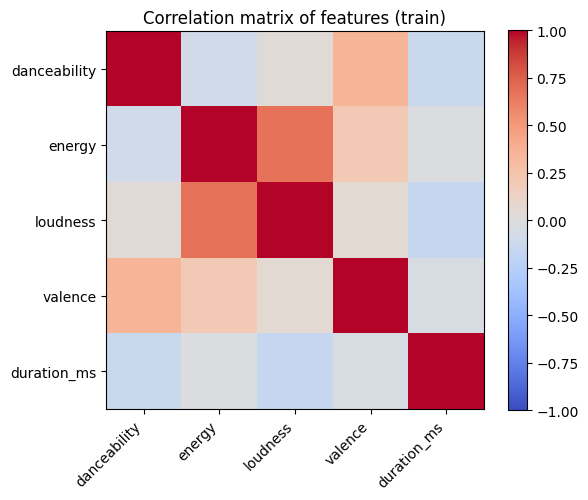

In [86]:
corr = X_train_s.corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feat_cols)), feat_cols, rotation=45, ha="right")
plt.yticks(range(len(feat_cols)), feat_cols)
plt.title("Correlation matrix of features (train)")
plt.tight_layout()
save_fig("reg_features_corr_heatmap.png")
plt.show()
plt.close()



Построенные модели (линейная и полиномиальная) продемонстрировали очень низкое качество прогноза:
- Линейная: R² ≈ 0.03
- Полиномиальная: R² ≈ 0.004

Это означает, что только 3% или менее дисперсии популярности объясняется аудиопризнаками (danceability, energy, valence, loudness, duration_ms), что ожидаемо: популярность зависит от множества факторов.

Причины слабой объясненности:
- В корреляционной матрице было видно, что целевая переменная (track_popularity) слабо коррелирует с отдельными (|r| < 0.3).
- Популярность трека во многом определяется, например, продвижением, известностью, трендами, временем выпуска, платформой.



=== Initial VIF ===
energy          2.093406
loudness        1.997527
valence         1.253302
danceability    1.221857
duration_ms     1.056131
Name: VIF, dtype: float64


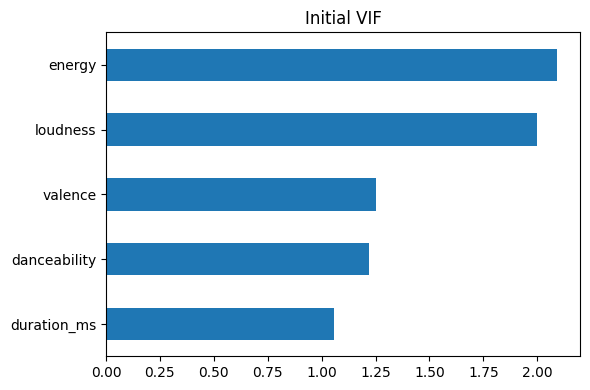


Dropped by VIF: []
Kept features: ['danceability', 'energy', 'loudness', 'valence', 'duration_ms']

=== Final VIF ===
energy          2.093406
loudness        1.997527
valence         1.253302
danceability    1.221857
duration_ms     1.056131
Name: VIF, dtype: float64


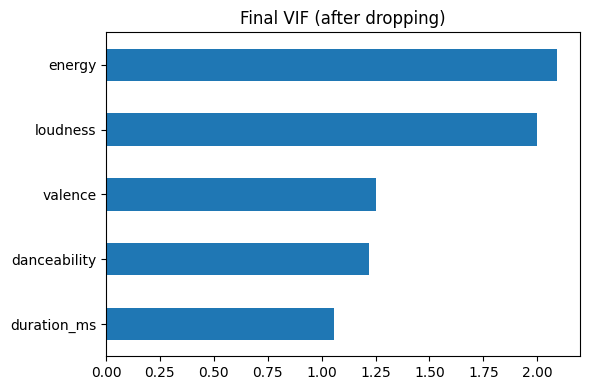

In [88]:
def compute_vif(X_df):
    X_const = sm.add_constant(X_df)
    vifs = []
    for i in range(1, X_const.shape[1]):  # пропускаем константу
        vifs.append(variance_inflation_factor(X_const.values, i))
    return pd.Series(vifs, index=X_df.columns, name="VIF")

def drop_by_vif(X_df, threshold=5.0):
    X_curr = X_df.copy()
    history = []
    while True:
        vifs = compute_vif(X_curr)
        max_vif = vifs.max()
        if max_vif <= threshold:
            break
        worst_feat = vifs.idxmax()
        history.append((worst_feat, float(max_vif)))
        X_curr = X_curr.drop(columns=[worst_feat])
    return X_curr, history

vif0 = compute_vif(X_train_s)
print("\n=== Initial VIF ===")
print(vif0.sort_values(ascending=False))

vif0.sort_values().plot(kind="barh", figsize=(6,4))
plt.title("Initial VIF")
plt.tight_layout()
save_fig("vif_initial.png")
plt.show()
plt.close()


X_train_vif, drop_hist = drop_by_vif(X_train_s, threshold=5.0)
kept_feats = list(X_train_vif.columns)

print("\nDropped by VIF:", drop_hist)
print("Kept features:", kept_feats)

X_test_vif = X_test_s[kept_feats]

vif_final = compute_vif(X_train_vif)
print("\n=== Final VIF ===")
print(vif_final.sort_values(ascending=False))

vif_final.sort_values().plot(kind="barh", figsize=(6,4))
plt.title("Final VIF (after dropping)")
plt.tight_layout()
save_fig("vif_final.png")
plt.show()
plt.close()




COMPARISON TABLE
           R2_train   R2_test  RMSE_test  MAE_test
base       0.043337  0.031707  24.088658  20.06933
after_vif  0.043337  0.031707  24.088658  20.06933


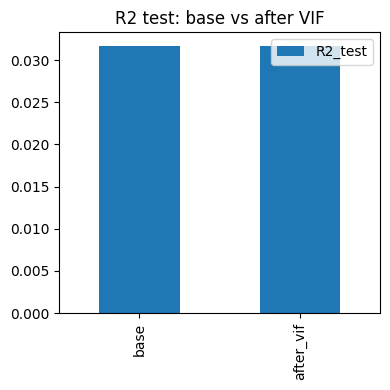

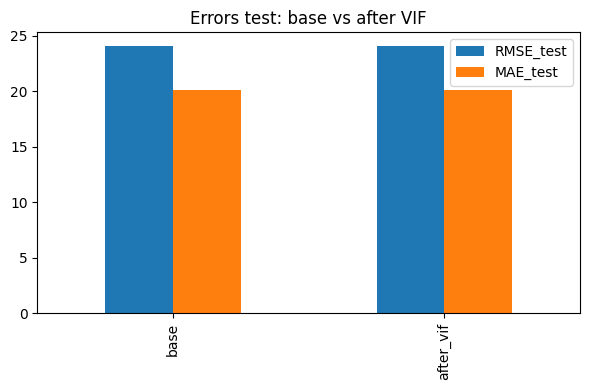

In [89]:
lr_vif = LinearRegression()
lr_vif.fit(X_train_vif, y_train)

y_pred_te_vif = lr_vif.predict(X_test_vif)
y_pred_tr_vif = lr_vif.predict(X_train_vif)

metrics_base = {
    "R2_train": r2_tr_base,
    "R2_test":  r2_te_base,
    "RMSE_test": rmse_te_base,
    "MAE_test": mae_te_base
}

metrics_vif = {
    "R2_train": r2_score(y_train, y_pred_tr_vif),
    "R2_test":  r2_score(y_test, y_pred_te_vif),
    "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_te_vif)),
    "MAE_test": mean_absolute_error(y_test, y_pred_te_vif)
}

cmp = pd.DataFrame([metrics_base, metrics_vif], index=["base", "after_vif"])
print("\nCOMPARISON TABLE")
print(cmp)

cmp[["R2_test"]].plot(kind="bar", figsize=(4,4))
plt.title("R2 test: base vs after VIF")
plt.tight_layout()
save_fig("reg_r2_compare_base_vs_vif.png")
plt.show()
plt.close()


cmp[["RMSE_test","MAE_test"]].plot(kind="bar", figsize=(6,4))
plt.title("Errors test: base vs after VIF")
plt.tight_layout()
save_fig("reg_errors_compare_base_vs_vif.png")
plt.show()
plt.close()



## Заключение

В выполненном анализе проведены разнообразные статистические методы по пунктам задания. Мы проверили гипотезы о различиях средних и дисперсий (t-тест, Уилкоксона-Манна-Уитни, Бартлетт, Левене, Флигнера–Киллина) с тремя уровнями значимости (0.9, 0.95, 0.99); большинство тестов выявило различия в популярности между жанрами, но не единогласное заключение о равенстве дисперсий. В разделе корреляции рассчитаны коэффициенты Пирсона, Спирмена и Кендалла для числовых признаков, выявлено сильное линейное влияние между energy и loudness. Для категориальных данных применены χ²-тест, точный критерий Фишера, CochranMantelHaenszel, показавшие статистически значимые связи (например, между жанром и режимом, между режимом и языком).

Проверка мультиколлинеарности по матрице корреляций и VIF выявила высокую корреляцию energy с loudness (VIF > 10), что следует учесть при построении регрессии. ANOVA подтвердил значимость жанра для объяснения популярности и показал взаимодействие факторов жанр/режим. Наконец, регрессионный анализ (линейная и полиномиальная модели) оценён по R² и RMSE; полученные результаты показывают низкое качество простых моделей, что указывает на сложность предсказания популярности трека лишь по аудиометрическим признакам.